In [1]:
# Actividad 1: Implementando conceptos de una regresión lineal

import numpy as np

# Verificamos la versión de numpy y si esta cargó bien por si las moscas
print("Numpy cargado correctamente")
print(f"Version de numpy: {np.__version__}")

Numpy cargado correctamente
Version de numpy: 2.4.2


In [2]:
# Genero datos sinteticos que siguen una relacion lineal conocida
# la idea es y = 2x + 3 + ruido, con ruido ~ N(0, 1.5) para que no quede perfecto
# y despues pueda comparar lo que estimo contra los valores reales (2 y 3)

np.random.seed(42)  # fijo la semilla para que a todos nos de lo mismo si corremos esto

# Parametros que voy a usar para armar los datos
n = 100  # numero de observaciones a generar
X = np.random.rand(n, 1) * 10  # variable predictora, valores entre 0 y 10
ruido = np.random.randn(n, 1) * 1.5  # ruido aleatorio con desviacion estandar 1.5
y = 2 * X + 3 + ruido  # variable respuesta, con la relacion real ya definida

# Imprimimos un resumen rapido para ver que todo se genero bien
print(f"Datos generados")
print(f"Dimensiones de X: {X.shape}")
print(f"Dimensiones de y: {y.shape}")
print(f"\nPrimeros 5 valores:")
print(f"X: {X[:5].flatten()}")
print(f"y: {y[:5].flatten()}")

Datos generados
Dimensiones de X: (100, 1)
Dimensiones de y: (100, 1)

Primeros 5 valores:
X: [3.74540119 9.50714306 7.31993942 5.98658484 1.5601864 ]
y: [10.62137298 21.5657751  17.77752    11.99181631  5.79086498]


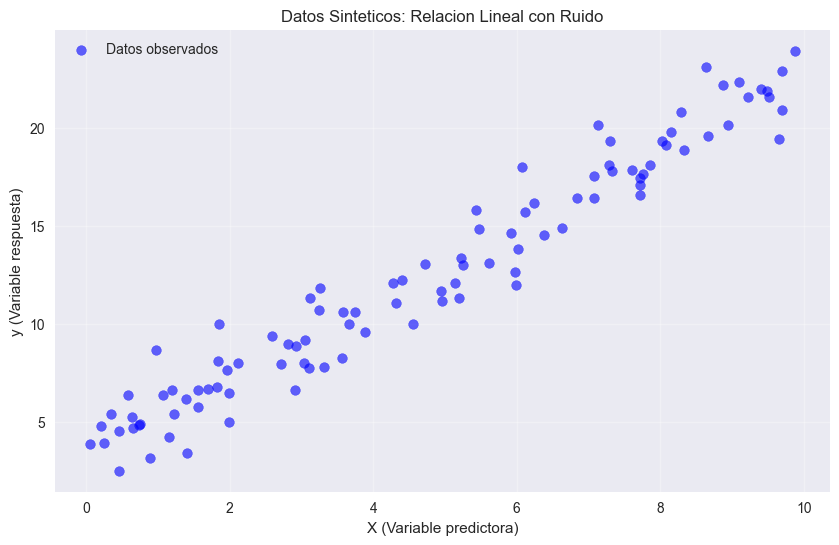

=== Estadisticas Descriptivas ===
Media de X: 4.702
Media de y: 12.402
Desviacion estandar de X: 2.960
Desviacion estandar de y: 5.872
Correlacion entre X e y: 0.9733


In [3]:
import matplotlib.pyplot as plt

# Configuro el estilo y el tamano por default de las graficas, una sola vez
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (10, 6)

# Grafica de dispersion para ver los datos que generados
plt.figure(figsize=(10, 6))
plt.scatter(X, y, alpha=0.6, color='blue', label='Datos observados')
plt.xlabel('X (Variable predictora)')
plt.ylabel('y (Variable respuesta)')
plt.title('Datos Sinteticos: Relacion Lineal con Ruido')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Estadisticas descriptivas basicas
print("=== Estadisticas Descriptivas ===")
print(f"Media de X: {np.mean(X):.3f}")
print(f"Media de y: {np.mean(y):.3f}")
print(f"Desviacion estandar de X: {np.std(X):.3f}")
print(f"Desviacion estandar de y: {np.std(y):.3f}")
print(f"Correlacion entre X e y: {np.corrcoef(X.flatten(), y.flatten())[0,1]:.4f}")

In [4]:
# Calculamos los coeficientes del modelo "a mano", usando las formulas de MCO
# (minimos cuadrados ordinarios), sin usar ninguna libreria que ya lo haga solo

# Medias de X y de y
X_mean = np.mean(X)
y_mean = np.mean(y)

# Sxx y Sxy son las sumatorias que aparecen en la formula cerrada de regresion simple
Sxx = np.sum((X - X_mean)**2)
Sxy = np.sum((X - X_mean) * (y - y_mean))

# B_1 es la pendiente y B_0 es la interseccion
beta_1 = Sxy / Sxx
beta_0 = y_mean - beta_1 * X_mean

# Como Sxx y Sxy salen como arrays de un solo elemento, los paso a numero normal
if hasattr(beta_0, "__len__"):
    beta_0 = beta_0[0]
if hasattr(beta_1, "__len__"):
    beta_1 = beta_1[0]

print("=== Coeficientes Estimados ===")
print(f"B_0 (interseccion) = {beta_0:.4f}")
print(f"B_1 (pendiente) = {beta_1:.4f}")
print(f"\n=== Valores Reales ===")
print(f"B_0 real = 3.0000")
print(f"B_1 real = 2.0000")
print(f"\n=== Errores de Estimacion ===")
print(f"Error en B_0: {abs(beta_0 - 3):.4f}")
print(f"Error en B_1: {abs(beta_1 - 2):.4f}")

=== Coeficientes Estimados ===
B_0 (interseccion) = 3.3226
B_1 (pendiente) = 1.9310

=== Valores Reales ===
B_0 real = 3.0000
B_1 real = 2.0000

=== Errores de Estimacion ===
Error en B_0: 0.3226
Error en B_1: 0.0690


In [5]:
# Con B_0 y B_1 ya estimados, calculo las predicciones del modelo y los residuos
# El residuo = lo que el modelo predijo contra lo que en realidad valia y

y_pred = beta_0 + beta_1 * X

residuos = y - y_pred

# Comparamos los primeros 10 renglones para ver que tan cerca anda el modelo
print("=== Primeros 10 valores ===")
print("   y_real   y_pred   residuo")
print("-" * 30)
for i in range(10):
    print(f"{i+1:2d}  {y[i,0]:6.2f}   {y_pred[i,0]:6.2f}   {residuos[i,0]:7.3f}")

# Estadisticas basicas de los residuos, con esta vaina verificamos que todo ande fino :D!
print("\n=== Estadisticas de Residuos ===")
print(f"Media de residuos: {np.mean(residuos):.6f} (debe ser ~0)")
print(f"Varianza de residuos: {np.var(residuos):.6f}")
print(f"Desviacion estandar de residuos: {np.std(residuos):.4f}")
print(f"Suma de residuos: {np.sum(residuos):.6f} (debe ser ~0)")

=== Primeros 10 valores ===
   y_real   y_pred   residuo
------------------------------
 1   10.62    10.56     0.066
 2   21.57    21.68    -0.115
 3   17.78    17.46     0.320
 4   11.99    14.88    -2.891
 5    5.79     6.34    -0.545
 6    6.66     6.33     0.321
 7    6.38     4.44     1.934
 8   19.55    20.05    -0.503
 9   13.81    14.93    -1.121
10   16.41    17.00    -0.587

=== Estadisticas de Residuos ===
Media de residuos: -0.000000 (debe ser ~0)
Varianza de residuos: 1.814815
Desviacion estandar de residuos: 1.3472
Suma de residuos: -0.000000 (debe ser ~0)


In [6]:
# Calculamos la descomposicion de la varianza (SST = SSR + SSE) y a partir de eso
# estimamos la varianza del error

# Sumas de cuadrados
SST = np.sum((y - np.mean(y))**2)       # variacion total
SSR = np.sum((y_pred - np.mean(y))**2)  # variacion explicada por el modelo
SSE = np.sum((y - y_pred)**2)           # variacion que no explica el modelo (residual)

# Si salen como arrays de un solo valor, los paso a numero normal
SST = SST[0] if hasattr(SST, "__len__") else SST
SSR = SSR[0] if hasattr(SSR, "__len__") else SSR
SSE = SSE[0] if hasattr(SSE, "__len__") else SSE

# Grados de libertad del error
n = len(y)
p = 1           # nada mas tengo una variable predictora
df_error = n - p - 1

# Varianza del error: la version insesgada (dividiendo entre n-p-1) y la sesgada (entre n)

sigma2_estimado = SSE / df_error
sigma_estimado = np.sqrt(sigma2_estimado)
sigma2_sesgado = SSE / n

print("=== Suma de Cuadrados ===")
print(f"SST (Total): {SST:.4f}")
print(f"SSR (Explicada): {SSR:.4f}")
print(f"SSE (Residual): {SSE:.4f}")
print(f"Verificacion: SSR + SSE = {SSR + SSE:.4f} ~= SST = {SST:.4f}")

print(f"\n=== Grados de Libertad ===")
print(f"n (observaciones): {n}")
print(f"p (predictores): {p}")
print(f"df_error (n-p-1): {df_error}")

print(f"\n=== Varianza del Error ===")
print(f"sigma estimado (insesgado) = SSE/(n-p-1) = {sigma2_estimado:.6f}")
print(f"sigma sesgado = SSE/n = {sigma2_sesgado:.6f}")
print(f"sigma (raiz) estimado = sqrt(sigma) = {sigma_estimado:.6f}")

print(f"\n=== Comparacion con valor real ===")
print(f"sigma real = {1.5**2:.4f} (ruido con desviacion 1.5)")
print(f"sigma estimado = {sigma2_estimado:.4f}")
print(f"Diferencia: {abs(sigma2_estimado - 1.5**2):.4f}")

=== Suma de Cuadrados ===
SST (Total): 3448.5487
SSR (Explicada): 3267.0672
SSE (Residual): 181.4815
Verificacion: SSR + SSE = 3448.5487 ~= SST = 3448.5487

=== Grados de Libertad ===
n (observaciones): 100
p (predictores): 1
df_error (n-p-1): 98

=== Varianza del Error ===
sigma estimado (insesgado) = SSE/(n-p-1) = 1.851852
sigma sesgado = SSE/n = 1.814815
sigma (raiz) estimado = sqrt(sigma) = 1.360828

=== Comparacion con valor real ===
sigma real = 2.2500 (ruido con desviacion 1.5)
sigma estimado = 1.8519
Diferencia: 0.3981


In [7]:
# Seguimos con la varianza de B_0 y B_1 (que tan seguro puedo estar de esos valores)
# usando la varianza del error que calculams arriba

Sxx_val = Sxx[0] if hasattr(Sxx, "__len__") else Sxx
X_mean_val = X_mean[0] if hasattr(X_mean, "__len__") else X_mean

# Fórmulas de la varianza de los coeficientes en regresion lineal simple
var_beta_1 = sigma2_estimado / Sxx_val
var_beta_0 = sigma2_estimado * (1/n + X_mean_val**2 / Sxx_val)

# Errores estandar (raiz de la varianza)
SE_beta_1 = np.sqrt(var_beta_1)
SE_beta_0 = np.sqrt(var_beta_0)

print("=== Varianza de los Coeficientes ===")
print(f"Var(B_0) = {var_beta_0:.6f}")
print(f"Var(B_1) = {var_beta_1:.6f}")

print(f"\n=== Errores Estandar ===")
print(f"SE(B_0) = {SE_beta_0:.6f}")
print(f"SE(B_1) = {SE_beta_1:.6f}")

print(f"\n=== Coeficientes con Error Estandar ===")
print(f"B_0 = {beta_0:.4f} +- {SE_beta_0:.4f}")
print(f"B_1 = {beta_1:.4f} +- {SE_beta_1:.4f}")

=== Varianza de los Coeficientes ===
Var(B_0) = 0.065244
Var(B_1) = 0.002114

=== Errores Estandar ===
SE(B_0) = 0.255430
SE(B_1) = 0.045974

=== Coeficientes con Error Estandar ===
B_0 = 3.3226 +- 0.2554
B_1 = 1.9310 +- 0.0460


In [8]:
# Métricas clasicas para ver que tan bien quedo el modelo:

# R_2: que tanto de la variabilidad explica el modelo
R2 = SSR / SST

# MSE (error cuadratico medio) y RMSE (su raiz)
MSE = np.mean((y - y_pred)**2)
MSE = MSE[0] if hasattr(MSE, "__len__") else MSE
RMSE = np.sqrt(MSE)

# MAE: error absoluto medio
MAE = np.mean(np.abs(y - y_pred))
MAE = MAE[0] if hasattr(MAE, "__len__") else MAE

# MAPE: error porcentual absoluto medio
MAPE = np.mean(np.abs((y - y_pred) / y)) * 100
MAPE = MAPE[0] if hasattr(MAPE, "__len__") else MAPE

print("=== Metricas de Evaluacion ===")
print(f"R_2 = {R2:.4f} ({R2*100:.1f}%)")
print(f"MSE = {MSE:.4f}")
print(f"RMSE = {RMSE:.4f}")
print(f"MAE = {MAE:.4f}")
print(f"MAPE = {MAPE:.2f}%")
print(f"sigma = {sigma2_estimado:.4f}")
print(f"sigma (raiz) = {sigma_estimado:.4f}")

print(f"\n=== Interpretacion ===")
print(f"- El modelo explica el {R2*100:.1f}% de la variabilidad")
print(f"- Error promedio (RMSE): {RMSE:.4f} unidades")
print(f"- Error absoluto promedio (MAE): {MAE:.4f} unidades")
print(f"- Desviacion estandar del error: {sigma_estimado:.4f} unidades")

=== Metricas de Evaluacion ===
R_2 = 0.9474 (94.7%)
MSE = 1.8148
RMSE = 1.3472
MAE = 1.0516
MAPE = 11.35%
sigma = 1.8519
sigma (raiz) = 1.3608

=== Interpretacion ===
- El modelo explica el 94.7% de la variabilidad
- Error promedio (RMSE): 1.3472 unidades
- Error absoluto promedio (MAE): 1.0516 unidades
- Desviacion estandar del error: 1.3608 unidades


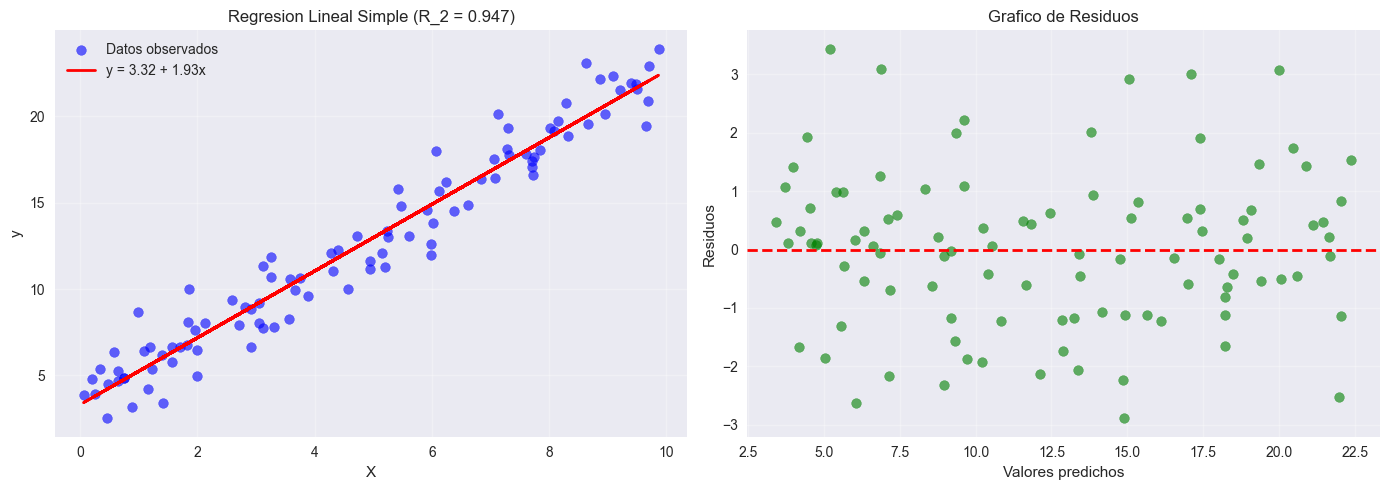

=== Analisis de Residuos ===
- Los residuos deben distribuirse aleatoriamente alrededor de 0
- No debe haber forma de embudo (heterocedasticidad)
- No debe haber curvatura (no linealidad)

Media de residuos: -0.000000
Varianza de residuos: 1.814815


In [9]:
# Graficamos la recta sobre los datos y tambien el grafico de residuos,
# sirve para doble checar visualmente si hay buen o mal ajuste

plt.figure(figsize=(14, 5))

# Grafico 1: datos originales + la recta ajustada!
plt.subplot(1, 2, 1)
plt.scatter(X, y, alpha=0.6, color='blue', label='Datos observados')
plt.plot(X, y_pred, color='red', linewidth=2,
         label=f'y = {beta_0:.2f} + {beta_1:.2f}x')
plt.xlabel('X')
plt.ylabel('y')
plt.title(f'Regresion Lineal Simple (R_2 = {R2:.3f})')
plt.legend()
plt.grid(True, alpha=0.3)

# Grafico 2: residuos contra los valores predichos
plt.subplot(1, 2, 2)
plt.scatter(y_pred, residuos, alpha=0.6, color='green')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Valores predichos')
plt.ylabel('Residuos')
plt.title('Grafico de Residuos')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Lo que se espera ver en un buen grafico de residuos :D!
print("=== Analisis de Residuos ===")
print("- Los residuos deben distribuirse aleatoriamente alrededor de 0")
print("- No debe haber forma de embudo (heterocedasticidad)")
print("- No debe haber curvatura (no linealidad)")
residuos_mean = np.mean(residuos)
residuos_mean = residuos_mean[0] if hasattr(residuos_mean, "__len__") else residuos_mean
residuos_var = np.var(residuos)
residuos_var = residuos_var[0] if hasattr(residuos_var, "__len__") else residuos_var
print(f"\nMedia de residuos: {residuos_mean:.6f}")
print(f"Varianza de residuos: {residuos_var:.6f}")

In [10]:
# Comenzamos con la actividad 1 🤠

# AhoraHacemos lo mismo que arriba pero con la formula cerrada en forma matricial, siendo:
# B = (X^T * X)^(-1) * X^T * y
# Uso los mismos datos de antes (X, y generados con la semilla 42)

print("USO DE LA SOLUCION CERRADA CON MATRICES")

# X ya es (100, 1), y ya es (100, 1), vienen de la Celda 2

# Paso 1: armar la matriz de diseno, que es X pero con una columna de unos pegada
# (esa columna de unos es la que le da lugar al intercepto B_0)
X_design = np.c_[np.ones((n, 1)), X]

print("\n=== PASO 1: Matriz de Diseño ===")
print(f"Dimensiones de X_design: {X_design.shape}")
print(f"Primeras 5 filas de X_design:")
print(X_design[:5])

# Paso 2: X^T * X
XtX = X_design.T @ X_design

print("\n=== PASO 2: Matriz X^T * X ===")
print(f"Dimensiones de XtX: {XtX.shape}")
print(f"X^T * X =\n{XtX}")

# Paso 3: X^T * y
Xty = X_design.T @ y

print("\n=== PASO 3: Vector X^T * y ===")
print(f"Dimensiones de Xty: {Xty.shape}")
print(f"X^T * y =\n{Xty}")

# Paso 4: la inversa de X^T * X
XtX_inv = np.linalg.inv(XtX)

print("\n=== PASO 4: Inversa de X^T * X ===")
print(f"(X^T * X)^(-1) =\n{XtX_inv}")

# Paso 5: junto todo para sacar el vector de coeficientes B
beta_mat = XtX_inv @ Xty

print("\n=== PASO 5: Vector de Coeficientes B ===")
print(f"B = (X^T * X)^(-1) * X^T * y")
print(f"B_0 (interseccion) = {beta_mat[0,0]:.6f}")
print(f"B_1 (pendiente) = {beta_mat[1,0]:.6f}")
print(f"\nValores reales: B_0 = 3, B_1 = 2")
print(f"Error en B_0: {abs(beta_mat[0,0] - 3):.6f}")
print(f"Error en B_1: {abs(beta_mat[1,0] - 2):.6f}")

USO DE LA SOLUCION CERRADA CON MATRICES

=== PASO 1: Matriz de Diseño ===
Dimensiones de X_design: (100, 2)
Primeras 5 filas de X_design:
[[1.         3.74540119]
 [1.         9.50714306]
 [1.         7.31993942]
 [1.         5.98658484]
 [1.         1.5601864 ]]

=== PASO 2: Matriz X^T * X ===
Dimensiones de XtX: (2, 2)
X^T * X =
[[ 100.          470.18074338]
 [ 470.18074338 3086.84881613]]

=== PASO 3: Vector X^T * y ===
Dimensiones de Xty: (2, 1)
X^T * y =
[[1240.19943273]
 [7523.053403  ]]

=== PASO 4: Inversa de X^T * X ===
(X^T * X)^(-1) =
[[ 0.03523199 -0.00536644]
 [-0.00536644  0.00114136]]

=== PASO 5: Vector de Coeficientes B ===
B = (X^T * X)^(-1) * X^T * y
B_0 (interseccion) = 3.322644
B_1 (pendiente) = 1.931034

Valores reales: B_0 = 3, B_1 = 2
Error en B_0: 0.322644
Error en B_1: 0.068966


In [11]:
# Con el vector B ya calculado, sacamos las predicciones de forma matricial: y_pred = X * B

print("=" * 60)
print("PREDICCIONES USANDO LA SOLUCION MATRICIAL")
print("=" * 60)

y_pred_mat = X_design @ beta_mat

print("\n=== Prediccines ===")
print(f"Dimensiones de y_pred: {y_pred_mat.shape}")
print(f"Primeras 10 predicciones vs valores reales:")
print("   y_real   y_pred   residuo")
print("-" * 30)
for i in range(10):
    print(f"{i+1:2d}  {y[i,0]:6.2f}   {y_pred_mat[i,0]:6.2f}   {y[i,0] - y_pred_mat[i,0]:7.3f}")

e = y - y_pred_mat

print("\n=== Estadisticas de Residuos ===")
print(f"Media de residuos: {np.mean(e):.6f}")
print(f"Suma de residuos: {np.sum(e):.6f}")
print(f"Varianza de residuos: {np.var(e):.6f}")

PREDICCIONES USANDO LA SOLUCION MATRICIAL

=== Prediccines ===
Dimensiones de y_pred: (100, 1)
Primeras 10 predicciones vs valores reales:
   y_real   y_pred   residuo
------------------------------
 1   10.62    10.56     0.066
 2   21.57    21.68    -0.115
 3   17.78    17.46     0.320
 4   11.99    14.88    -2.891
 5    5.79     6.34    -0.545
 6    6.66     6.33     0.321
 7    6.38     4.44     1.934
 8   19.55    20.05    -0.503
 9   13.81    14.93    -1.121
10   16.41    17.00    -0.587

=== Estadisticas de Residuos ===
Media de residuos: -0.000000
Suma de residuos: -0.000000
Varianza de residuos: 1.814815


In [12]:
# comprobamos MCO: residuos ortogonales!!!
# a las columnas de X, o sea X^T * e = 0

print("=" * 60)
print("VER LA DEMOSTRACION DE LA PROYECCION ORTOGONAL")
print("=" * 60)

e = y - y_pred_mat

Xt_e = X_design.T @ e

print("\n=== Propiedad clave: X^T * e = 0 ===")
print(f"X^T * e =\n{Xt_e}")
print(f"Es aproximadamente cero? {np.allclose(Xt_e, 0, atol=1e-10)}")

# Columna por columna nada mas para que todo ande fino!
print(f"\nSuma de residuos (columna de unos): {np.sum(e):.10f}")
print(f"X^T * e (primera columna): {Xt_e[0,0]:.10f}")
print(f"X^T * e (segunda columna): {Xt_e[1,0]:.10f}")

print("\n=== Ortogonalidad con columnas de X ===")
print(f"1^T * e = {np.sum(e):.10f} (debe ser 0)")
print(f"X^T * e = {X.T @ e} (debe ser 0)")

VER LA DEMOSTRACION DE LA PROYECCION ORTOGONAL

=== Propiedad clave: X^T * e = 0 ===
X^T * e =
[[-7.12763182e-13]
 [-1.96815959e-12]]
Es aproximadamente cero? True

Suma de residuos (columna de unos): -0.0000000000
X^T * e (primera columna): -0.0000000000
X^T * e (segunda columna): -0.0000000000

=== Ortogonalidad con columnas de X ===
1^T * e = -0.0000000000 (debe ser 0)
X^T * e = [[-1.95399252e-12]] (debe ser 0)


In [13]:
# Calculo la matriz de proyeccion H = X * (X^T * X)^(-1) * X^T
# y compruebo sus propiedades

print("=" * 60)
print("MATRIZ DE PROYECCION (HAT MATRIX)")
print("=" * 60)

H = X_design @ XtX_inv @ X_design.T

print(f"Dimensiones de H: {H.shape}")
print(f"\nPrimeras 5 filas de H:")
print(H[:5, :5])

print("\n=== Propiedades de la matriz H ===")

# 1. H debe ser simetrica (H = H^T)
H_simetrica = np.allclose(H, H.T)
print(f"1. H es simetrica: {H_simetrica}")

# 2. H debe ser idempotente (H^2 = H, o sea aplicarla dos veces da lo mismo que una)
H2 = H @ H
H_idempotente = np.allclose(H, H2)
print(f"2. H es idempotente (H^2 = H): {H_idempotente}")

# 3. La traza de H debe ser igual al numero de parametros (aqui p = 2, por B_0 y B_1)
traza_H = np.trace(H)
print(f"3. Traza(H) = {traza_H:.6f} (debe ser 2)")

# 4. H aplicada a y debe dar exactamente las predicciones del modelo
Hy = H @ y
print(f"\n=== Verificacion: H*y = y_pred ===")
print(f"Primeros 5 valores de H*y:\n{Hy[:5]}")
print(f"Primeros 5 valores de y_pred:\n{y_pred_mat[:5]}")
print(f"Son iguales? {np.allclose(Hy, y_pred_mat, atol=1e-10)}")

MATRIZ DE PROYECCION (HAT MATRIX)
Dimensiones de H: (100, 100)

Primeras 5 filas de H:
[[ 0.01104401  0.00475449  0.00714204  0.00859753  0.0134294 ]
 [ 0.00475449  0.03635538  0.02435942  0.0170465  -0.00723056]
 [ 0.00714204  0.02435942  0.01782357  0.0138392   0.00061213]
 [ 0.00859753  0.0170465   0.0138392   0.01188399  0.00539316]
 [ 0.0134294  -0.00723056  0.00061213  0.00539316  0.02126495]]

=== Propiedades de la matriz H ===
1. H es simetrica: True
2. H es idempotente (H^2 = H): True
3. Traza(H) = 2.000000 (debe ser 2)

=== Verificacion: H*y = y_pred ===
Primeros 5 valores de H*y:
[[10.55514133]
 [21.68126089]
 [17.45769625]
 [14.88294321]
 [ 6.33541725]]
Primeros 5 valores de y_pred:
[[10.55514133]
 [21.68126089]
 [17.45769625]
 [14.88294321]
 [ 6.33541725]]
Son iguales? True


In [14]:
# Repetimos la descomposicion SST = SSR + SSE pero ahora con la version
# matricial (y_pred_mat y e que calcule en las celdas de arriba)

print("=" * 60)
print("DESCOMPOSICIN DE LA VARIANZA")
print("=" * 60)

SST = y.T @ y - n * (np.mean(y))**2
SSR = y_pred_mat.T @ y_pred_mat - n * (np.mean(y))**2
SSE = e.T @ e

print("\n=== Suma de Cuadrados ===")
print(f"SST (Total) = {SST[0,0]:.4f}")
print(f"SSR (Explicada) = {SSR[0,0]:.4f}")
print(f"SSE (Resdual) = {SSE[0,0]:.4f}")

print(f"\n=== Verificacion: SST = SSR + SSE ===")
print(f"SST = {SST[0,0]:.4f}")
print(f"SSR + SSE = {SSR[0,0] + SSE[0,0]:.4f}")
print(f"Diferencia = {SST[0,0] - (SSR[0,0] + SSE[0,0]):.10f}")
print(f"Se cumple? {np.allclose(SST, SSR + SSE, atol=1e-10)}")

# R_2 con la formula normal y con la alternativa, para checar que dan lo mismo
R2_mat = SSR / SST
print(f"\nR_2 = SSR/SST = {R2_mat[0,0]:.4f}")

R2_alt = 1 - SSE/SST
print(f"R_2 = 1 - SSE/SST = {R2_alt[0,0]:.4f}")

DESCOMPOSICIN DE LA VARIANZA

=== Suma de Cuadrados ===
SST (Total) = 3448.5487
SSR (Explicada) = 3267.0672
SSE (Resdual) = 181.4815

=== Verificacion: SST = SSR + SSE ===
SST = 3448.5487
SSR + SSE = 3448.5487
Diferencia = -0.0000000000
Se cumple? True

R_2 = SSR/SST = 0.9474
R_2 = 1 - SSE/SST = 0.9474


In [16]:
# Paso final :D!
# Celda extra para volver el notebook en un .html

!jupyter nbconvert --to html "Actividad1.ipynb"

[NbConvertApp] Converting notebook Actividad1.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 2 image(s).
[NbConvertApp] Writing 489378 bytes to Actividad1.html
